# H-003 · Cointegration-break flat rule + window screens

**Pipeline A:** Part A freezes `BREAK_STAR` on default windows (`ols=252`, `adf=252`, `entry_z=2`, `z=60`). Part B screens OLS / ADF / entry / z **under** that break. Short borrow is not modeled (net Sharpe optimistic for Asia bank shorts).

## Sleeve kill / continue (Part A only — before Part B)

Metric = **median fold-val `ann_sharpe`** across WF folds (net of costs). Do **not** use sealed OOS for this decision.

| Band | Median fold-val Sharpe (best / chosen break arm) | Action |
|------|--------------------------------------------------|--------|
| Severe | **≤ −0.50** | **Shelve sleeve** — do not run Part B or H-004+ |
| Deeply negative | **(−0.50, −0.25]** | **Shelve** unless the arm beats `break_mode=off` by **≥ +0.25** Sharpe **or** median max DD improves by **≥ 5 pp** **and** `pct_adf_lt_0.05` while trading rises **≥ +10 pp** vs `off` |
| Soft negative | **(−0.25, 0]** | **Yellow — may continue** only if break clearly helped vs `off`; document why |
| Non-negative | **> 0** | Continue to Part B; freeze `BREAK_STAR` |

If shelve: stop; leave `OLS_WINDOW_STAR` / `ADF_WINDOW_STAR` / `ENTRY_Z_STAR` / `Z_WINDOW_STAR` unset; do not open H-004.

Part A arms: `off` | `block_05_flat_10` | `flat_05`. Part B sequential screens (not a joint grid).


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    fold_table,
    fold_val_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DAY_OLS_WINDOW,
    DAY_Z_WINDOW,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    load_universe_c_panels,
    lookbacks_for_bar,
    overlay_ols_hedge,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
PAIRS_STAR = list(stack["PAIRS_STAR"])

# Part A uses soft defaults; Part B freezes day-unit STARs.
OLS_DAY_GRID = (504, 252, 126, 63)  # 2y / 1y / 6m / quarterly
ADF_DAY_GRID = (504, 252, 126, 63)
ENTRY_Z_GRID = (1.5, 2.0, 2.5)
Z_DAY_GRID = (40, 60, 90)

print("stack keys:", sorted(stack))
print("PAIRS_STAR", PAIRS_STAR)
print("n_variants Part A break=3; Part B sequential", len(OLS_DAY_GRID), "+", len(ADF_DAY_GRID), "+", len(ENTRY_Z_GRID), "+", len(Z_DAY_GRID))


stack keys: ['BAR_STAR', 'HEDGE_STAR', 'KALMAN_DELTA_STAR', 'PAIRS_STAR', 'RESEARCH_IS_END_STAR']
PAIRS_STAR ['1398.HK|0939.HK', '1288.HK|3328.HK', '8306.T|8316.T']
n_variants Part A break=3; Part B sequential 4 + 4 + 3 + 3


## 1. Load frozen panel / PAIRS_STAR (OLS defaults — no Kalman yet)


In [2]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_c_panels(BAR, PAIRS_STAR, root=ROOT)
lb0 = lookbacks_for_bar(BAR)
# Rebuild with default day windows so Part A is comparable across bars.
train = overlay_ols_hedge(
    train,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 10592 OOS rows 3398


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,2005-09-29,8306.T|8316.T,8306.T,8316.T,794.893020,805.781966,767.670656,789.448547,1782.033531,1879.235357,1717.232234,1733.432617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-09-30,8306.T|8316.T,8306.T,8316.T,794.893202,833.004519,773.115306,811.226624,1749.632882,1798.233795,1701.031969,1733.432617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-10-03,8306.T|8316.T,8306.T,8316.T,794.893317,800.337791,751.337518,773.115417,1701.032155,1733.432807,1652.431236,1717.232422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-10-04,8306.T|8316.T,8306.T,8316.T,778.559552,784.004025,751.337190,762.226135,1701.031997,1701.031997,1636.230817,1668.631348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005-10-05,8306.T|8316.T,8306.T,8316.T,767.670608,784.004025,751.337190,762.226135,1636.230866,1652.431132,1594.110033,1608.690308,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Part A · ADF break bake-off


### A.1 Walk-forward folds


In [3]:
panel = is_panel.copy()
dates = pd.DatetimeIndex(pd.to_datetime(panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,2005-09-29,2009-10-13,1050,2009-10-14,2009-10-20,2009-10-21,2013-11-13,1055
1,2,2005-09-29,2013-11-06,2105,2013-11-07,2013-11-13,2013-11-14,2017-12-08,1055
2,3,2005-09-29,2017-12-01,3160,2017-12-04,2017-12-08,2017-12-11,2021-12-31,1055


### A.2 Fold-val metrics (validation only)


In [4]:
configs_break = {
    "off": config_from_stack(stack, break_mode="off"),
    "block_05_flat_10": config_from_stack(stack, break_mode="block_05_flat_10"),
    "flat_05": config_from_stack(stack, break_mode="flat_05"),
}
fold_break = fold_val_metrics(panel, folds, configs_break, s1_weekly=s1_weekly)
fold_break


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,off,1,-0.455536,-0.088606,NaN,1053,38,0.890227,13.573501,13.573501
1,off,2,-1.100158,-0.172229,-0.049184,1053,53,1.000000,18.064261,18.064261
2,off,3,-0.927814,-0.144014,-0.068434,1053,53,1.000000,35.216892,35.216892
3,block_05_flat_10,1,-0.654204,-0.043336,NaN,1053,16,0.890227,13.573501,13.573501
4,block_05_flat_10,2,-0.999518,-0.063012,-0.055558,1053,18,1.000000,18.064261,18.064261
5,block_05_flat_10,3,-0.829615,-0.043814,-0.015164,1053,7,1.000000,35.216892,35.216892
6,flat_05,1,-0.749680,-0.048079,NaN,1053,20,0.890227,13.573501,13.573501
7,flat_05,2,-1.134050,-0.064921,0.005212,1053,20,1.000000,18.064261,18.064261
8,flat_05,3,-0.804262,-0.037741,-0.000484,1053,7,1.000000,35.216892,35.216892


### A.3 Boxplots (do not assign STAR here)


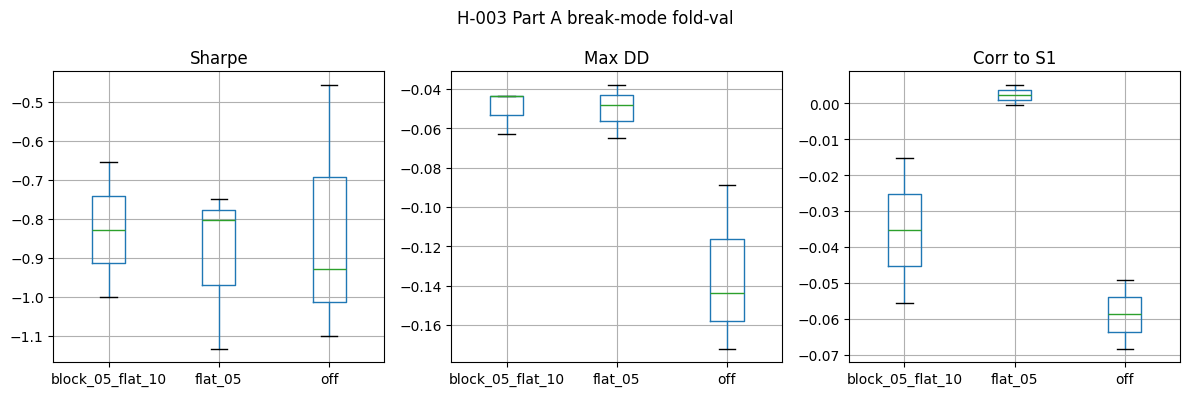

median-Sharpe hint (commentary only): flat_05


,ann_sharpe,max_drawdown,corr_to_s1
arm,,,
block_05_flat_10,-0.829615,-0.043814,-0.035361
flat_05,-0.804262,-0.048079,0.002364
off,-0.927814,-0.144014,-0.058809


In [5]:
plot_fold_boxplots(fold_break, title="H-003 Part A break-mode fold-val")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_break))
med_break = fold_break.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()
med_break


### A.4 Kill check then type `BREAK_STAR`

Apply the notebook-head kill table using `med_break`. If shelve, stop here. If continue, type `BREAK_STAR` manually (not argmax).


In [7]:
# After kill-table review:
BREAK_STAR = "flat_05"  # TODO: "off" | "block_05_flat_10" | "flat_05"
require_star("BREAK_STAR", BREAK_STAR)
stack["BREAK_STAR"] = BREAK_STAR
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH, "BREAK_STAR", BREAK_STAR)


wrote C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json BREAK_STAR flat_05


## Part B · Sequential screens under frozen `BREAK_STAR`

Run only if Part A did not shelve. Each stage freezes one STAR before the next. Boxplots of Sharpe / max DD / corr to S1; cost / gross commentary is manual from trade counts when useful. Day-unit grids; `lookbacks_for_bar` session-scales on 1h.


### B.1 OLS lookback screen → `OLS_WINDOW_STAR`


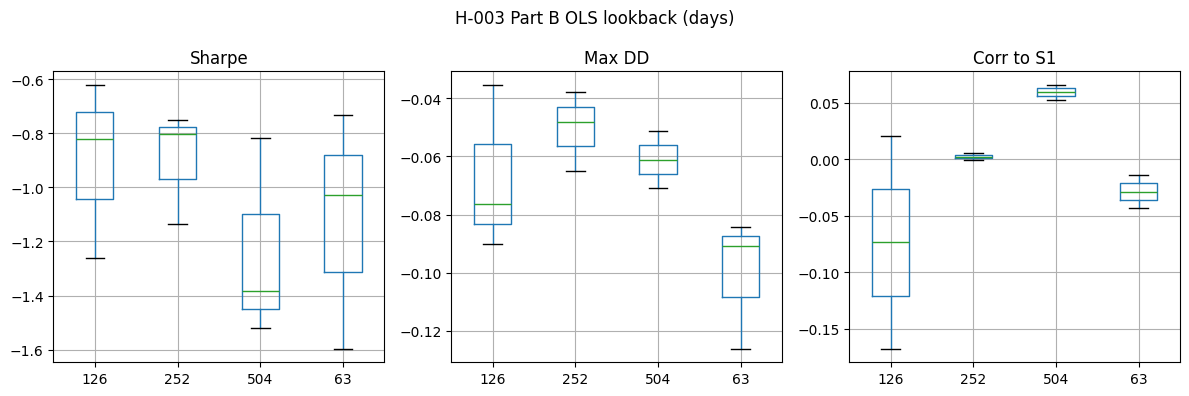

252


,ann_sharpe,max_drawdown,corr_to_s1
arm,,,
126,-0.822641,-0.076442,-0.073538
252,-0.804262,-0.048079,0.002364
504,-1.383516,-0.061144,0.059281
63,-1.028754,-0.090734,-0.028488


In [8]:
require_star("BREAK_STAR", stack.get("BREAK_STAR"))
configs_ols = {}
panels_ols = {}
for days in OLS_DAY_GRID:
    lb = lookbacks_for_bar(BAR, ols_days=days, z_days=DAY_Z_WINDOW, adf_days=DAY_OLS_WINDOW)
    p = overlay_ols_hedge(
        panel,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )
    panels_ols[days] = p
    configs_ols[str(days)] = config_from_stack(
        stack, ols_window=lb["ols_window"], z_window=lb["z_window"], adf_window=lb["adf_window"]
    )

# fold_val_metrics expects one panel; score each arm on its own overlay.
rows = []
for days, p in panels_ols.items():
    cfg = {str(days): configs_ols[str(days)]}
    part = fold_val_metrics(p, folds, cfg, s1_weekly=s1_weekly)
    rows.append(part)
fold_ols = pd.concat(rows, ignore_index=True)
plot_fold_boxplots(fold_ols, title="H-003 Part B OLS lookback (days)")
plt.show()
print(median_sharpe_hint(fold_ols))
fold_ols.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


In [9]:
OLS_WINDOW_STAR = None  # TODO day units: 504 | 252 | 126 | 63
require_star("OLS_WINDOW_STAR", OLS_WINDOW_STAR)
stack["OLS_WINDOW_STAR"] = int(OLS_WINDOW_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote OLS_WINDOW_STAR", OLS_WINDOW_STAR)


ValueError: OLS_WINDOW_STAR is None. Type it in the freeze cell after reviewing fold-val metrics.

### B.2 ADF window screen → `ADF_WINDOW_STAR`


In [ ]:
require_star("OLS_WINDOW_STAR", stack.get("OLS_WINDOW_STAR"))
ols_days = int(stack["OLS_WINDOW_STAR"])
rows = []
for days in ADF_DAY_GRID:
    lb = lookbacks_for_bar(BAR, ols_days=ols_days, z_days=DAY_Z_WINDOW, adf_days=days)
    p = overlay_ols_hedge(
        panel,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )
    cfg = {str(days): config_from_stack(
        stack, ols_window=lb["ols_window"], z_window=lb["z_window"], adf_window=lb["adf_window"]
    )}
    rows.append(fold_val_metrics(p, folds, cfg, s1_weekly=s1_weekly))
fold_adf = pd.concat(rows, ignore_index=True)
plot_fold_boxplots(fold_adf, title="H-003 Part B ADF window (days)")
plt.show()
print(median_sharpe_hint(fold_adf))
fold_adf.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


In [ ]:
ADF_WINDOW_STAR = None  # TODO day units: 504 | 252 | 126 | 63
require_star("ADF_WINDOW_STAR", ADF_WINDOW_STAR)
stack["ADF_WINDOW_STAR"] = int(ADF_WINDOW_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote ADF_WINDOW_STAR", ADF_WINDOW_STAR)


### B.3 Entry z screen → `ENTRY_Z_STAR`


In [ ]:
require_star("ADF_WINDOW_STAR", stack.get("ADF_WINDOW_STAR"))
ols_days = int(stack["OLS_WINDOW_STAR"])
adf_days = int(stack["ADF_WINDOW_STAR"])
lb = lookbacks_for_bar(BAR, ols_days=ols_days, z_days=DAY_Z_WINDOW, adf_days=adf_days)
panel_entry = overlay_ols_hedge(
    panel,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
configs_ez = {
    str(ez): config_from_stack(
        stack,
        entry_z=float(ez),
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        adf_window=lb["adf_window"],
    )
    for ez in ENTRY_Z_GRID
}
fold_ez = fold_val_metrics(panel_entry, folds, configs_ez, s1_weekly=s1_weekly)
plot_fold_boxplots(fold_ez, title="H-003 Part B entry_z")
plt.show()
print(median_sharpe_hint(fold_ez))
fold_ez.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


In [ ]:
ENTRY_Z_STAR = None  # TODO: 1.5 | 2.0 | 2.5
require_star("ENTRY_Z_STAR", ENTRY_Z_STAR)
stack["ENTRY_Z_STAR"] = float(ENTRY_Z_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote ENTRY_Z_STAR", ENTRY_Z_STAR)


### B.4 Z-window screen → `Z_WINDOW_STAR`


In [ ]:
require_star("ENTRY_Z_STAR", stack.get("ENTRY_Z_STAR"))
ols_days = int(stack["OLS_WINDOW_STAR"])
adf_days = int(stack["ADF_WINDOW_STAR"])
rows = []
for days in Z_DAY_GRID:
    lb = lookbacks_for_bar(BAR, ols_days=ols_days, z_days=days, adf_days=adf_days)
    p = overlay_ols_hedge(
        panel,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )
    cfg = {str(days): config_from_stack(
        stack,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        adf_window=lb["adf_window"],
    )}
    rows.append(fold_val_metrics(p, folds, cfg, s1_weekly=s1_weekly))
fold_z = pd.concat(rows, ignore_index=True)
plot_fold_boxplots(fold_z, title="H-003 Part B z_window (days)")
plt.show()
print(median_sharpe_hint(fold_z))
fold_z.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


In [ ]:
Z_WINDOW_STAR = None  # TODO day units: 40 | 60 | 90
require_star("Z_WINDOW_STAR", Z_WINDOW_STAR)
stack["Z_WINDOW_STAR"] = int(Z_WINDOW_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote Z_WINDOW_STAR", Z_WINDOW_STAR)


## Sealed OOS once (full frozen stack after Part B)


In [ ]:
stack = load_star_stack(STAR_PATH)
for key in ("BREAK_STAR", "OLS_WINDOW_STAR", "ADF_WINDOW_STAR", "ENTRY_Z_STAR", "Z_WINDOW_STAR"):
    require_star(key, stack.get(key))
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]),
    z_days=int(stack["Z_WINDOW_STAR"]),
    adf_days=int(stack["ADF_WINDOW_STAR"]),
)
oos_feat = overlay_ols_hedge(
    oos_panel,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
oos_cfg = config_from_stack(stack)
oos = run_s2_backtest(oos_feat, oos_cfg, s1_weekly=s1_weekly)
print(oos.metrics)
arm = f"{stack['BREAK_STAR']}_ols{stack['OLS_WINDOW_STAR']}_adf{stack['ADF_WINDOW_STAR']}_ez{stack['ENTRY_Z_STAR']}_z{stack['Z_WINDOW_STAR']}"
write_tearsheet_pdf(tearsheet_path("H-003", arm), oos.returns, title=f"H-003 sealed OOS {arm}")
print("tearsheet", tearsheet_path("H-003", arm))


## Notes for next hyp


H-004 Kalman β vs OLS hedge is next. Leave `BREAK_STAR` and window STARs frozen. Do not reopen Part A/B grids on sealed OOS.
